# Klasifikace LEGO minifigurek pomocí CNN

**Dataset:** LEGO Minifigures Classification — [Kaggle (ihelon)](https://www.kaggle.com/datasets/ihelon/lego-minifigures-classification)  
**Cíl:** Rozpoznání 38 různých postav LEGO ze čtyř sérií (Marvel, Star Wars, Harry Potter, Jurassic World)  
**Přístupy:** Vlastní CNN od nuly · Transfer Learning (MobileNetV2)

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

# GPU konfigurace
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU nalezeno: {gpus[0].name}")
else:
    print("UPOZORNENI: GPU nenalezeno – trening bezi na CPU (pomalu).")
    print("Pro GPU potrebujes CUDA 12.x + cuDNN. Zkontroluj: nvidia-smi")

DATA_DIR    = "data"
IMG_SIZE    = 96
BATCH_SIZE  = 16   # mene samplu/batch → vice aktualizaci vah za epochu
NUM_CLASSES = 38
EPOCHS      = 100

print(f"\nTensorFlow {tf.__version__}")

GPU nalezeno: /physical_device:GPU:0

TensorFlow 2.21.0


## 1. Dokumentace datasetu

In [37]:
df      = pd.read_csv(f"{DATA_DIR}/index.csv")
meta    = pd.read_csv(f"{DATA_DIR}/metadata.csv", encoding='cp1252')
df_test = pd.read_csv(f"{DATA_DIR}/test.csv")

df = df.merge(meta[['class_id', 'minifigure_name']], on='class_id')
df['series']    = df['path'].str.split('/').str[0]
df['full_path'] = DATA_DIR + '/' + df['path']
df_test['full_path'] = DATA_DIR + '/' + df_test['path']

class_counts = df.groupby('minifigure_name').size()

print(f"{'Trenovacich obrazku:':<32} {len(df)}")
print(f"{'Testovacich obrazku:':<32} {len(df_test)}")
print(f"{'Pocet trid:':<32} {df['class_id'].nunique()}")
print(f"{'Min / max / prumer / trida:':<32} {class_counts.min()} / {class_counts.max()} / {class_counts.mean():.1f}")
print()
print(df.groupby('series')['class_id'].nunique().rename('# trid').to_string())

Trenovacich obrazku:             371
Testovacich obrazku:             79
Pocet trid:                      38
Min / max / prumer / trida:      7 / 18 / 10.0

series
harry-potter       2
jurassic-world     2
marvel            17
star-wars         17


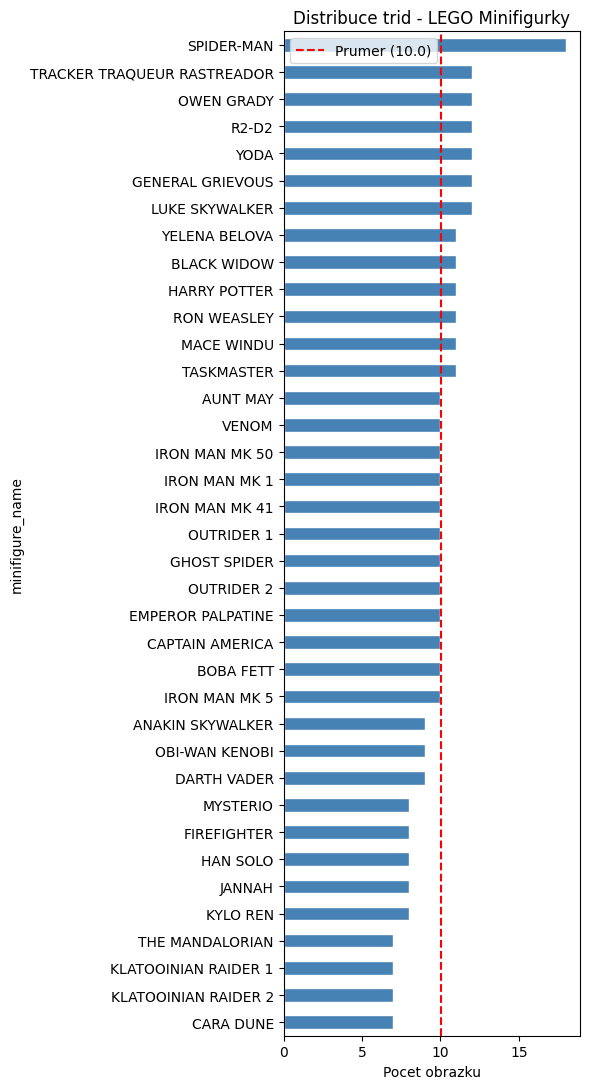

Dataset je velmi dobre vyvazeny (rozsah 7-18 obrazku na tridu).


In [38]:
fig, ax = plt.subplots(figsize=(6, 11))
class_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(class_counts.mean(), color='red', ls='--', lw=1.5,
           label=f'Prumer ({class_counts.mean():.1f})')
ax.set_xlabel('Pocet obrazku')
ax.set_title('Distribuce trid - LEGO Minifigurky')
ax.legend()
plt.tight_layout()
plt.show()
print("Dataset je velmi dobre vyvazeny (rozsah 7-18 obrazku na tridu).")

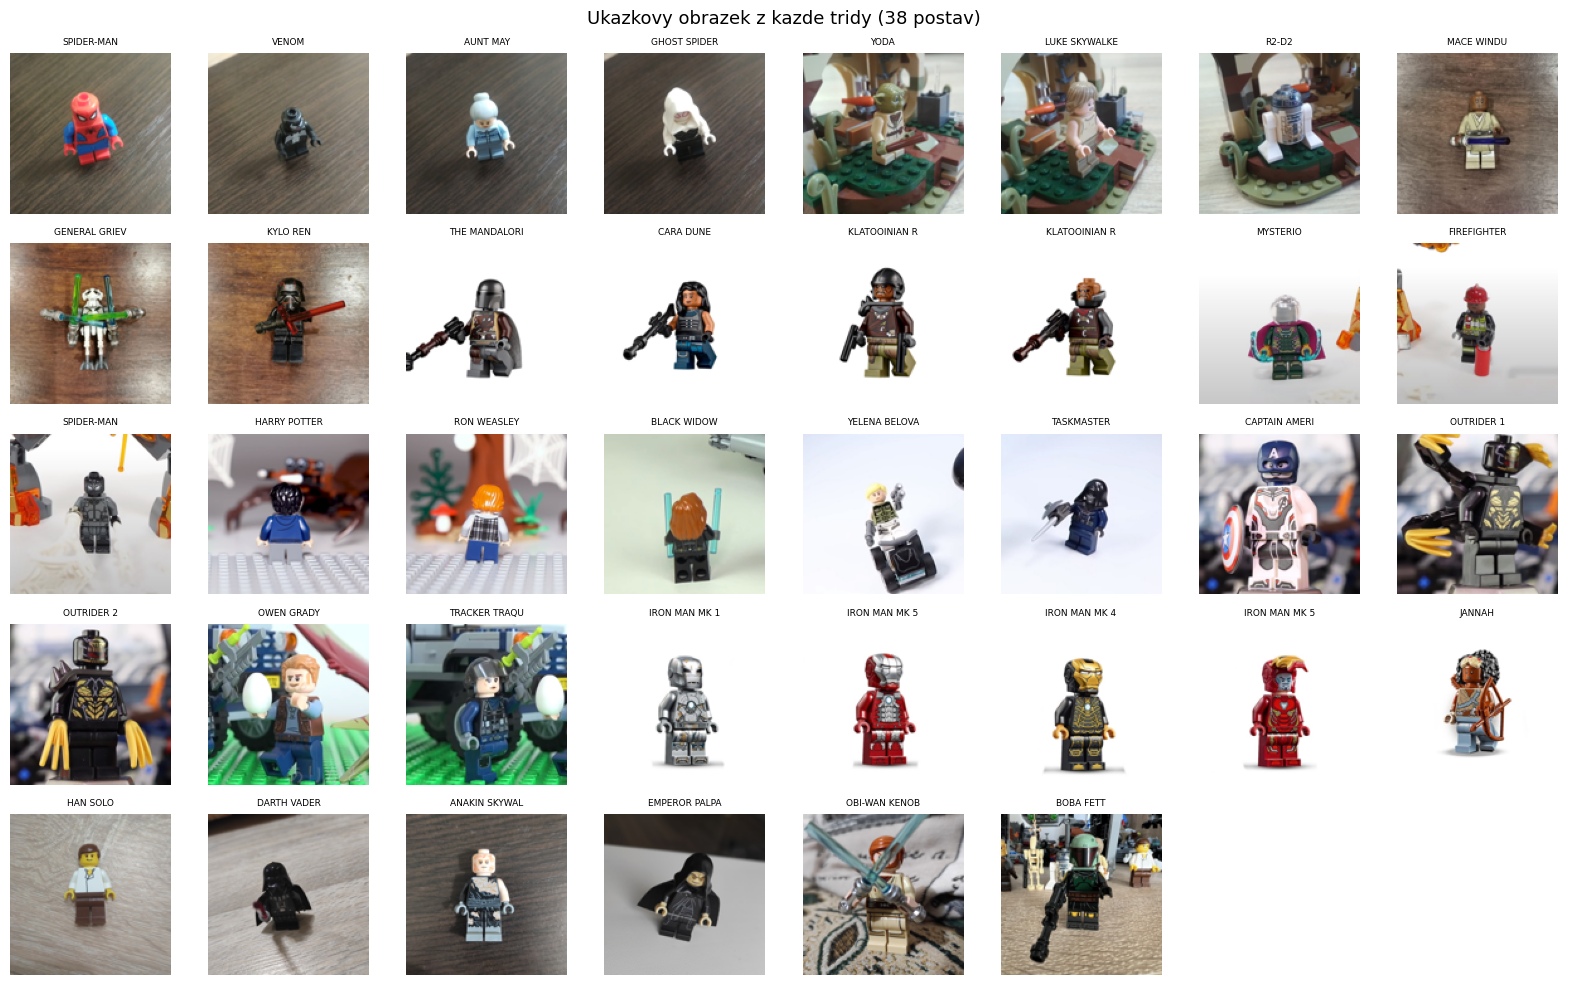

In [39]:
sample = df.groupby('class_id').first().reset_index()
fig, axes = plt.subplots(5, 8, figsize=(16, 10))
axes = axes.flatten()
for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row['full_path']).resize((128, 128))
    axes[i].imshow(img)
    axes[i].set_title(row['minifigure_name'][:13], fontsize=6.5)
    axes[i].axis('off')
for j in range(len(sample), len(axes)):
    axes[j].axis('off')
plt.suptitle('Ukazkovy obrazek z kazde tridy (38 postav)', fontsize=13)
plt.tight_layout()
plt.show()

**Pozorování:**
- Obrázky jsou 512×512 px, fotografie na bílém/neutrálním pozadí.
- Figurky mají stejné tělesné proporce — model musí rozlišit jemné detaily (barva, přílba, vzory na torzu).
- Extrémně malý dataset (~10 vzorků/třída) → nutná agresivní augmentace a transfer learning.

## 2. Příprava dat

In [40]:
def load_images(dataframe, img_size=IMG_SIZE):
    """Nacte obrazky do numpy pole, normalizuje do [0, 1]."""
    X, y = [], []
    for _, row in dataframe.iterrows():
        img = Image.open(row['full_path']).convert('RGB').resize((img_size, img_size))
        X.append(np.array(img, dtype=np.float32) / 255.0)
        y.append(int(row['class_id']) - 1)  # 0-indexovane
    return np.array(X), np.array(y)

# Stratifikovany split 80 / 20
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['class_id']
)
print(f"Trenink: {len(train_df)} | Validace: {len(val_df)} | Test: {len(df_test)}")

print("Nacitam obrazky...")
X_train, y_train = load_images(train_df)
X_val,   y_val   = load_images(val_df)
X_test,  y_test  = load_images(df_test)
print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

Trenink: 296 | Validace: 75 | Test: 79
Nacitam obrazky...
X_train: (296, 96, 96, 3)  X_val: (75, 96, 96, 3)  X_test: (79, 96, 96, 3)


## 3. Výběr hodnotících metrik

| Metrika | Popis |
|---|---|
| **Accuracy** | Celkový podíl správných predikcí |
| **F1-score (macro)** | Průměr F1 přes všechny třídy bez vážení — **hlavní metrika** |
| **Confusion matrix** | Vizualizace záměn mezi třídami |

**Hlavní metrika: F1-macro.**  
Přestože jsou třídy vyvážené, každá má jen 7–12 vzorků — F1-macro penalizuje špatnou klasifikaci
libovolné třídy stejnou měrou a lépe odhalí problémy s konkrétními podobnými postavami.
Accuracy je sekundární metrika pro snadnou interpretaci.

In [41]:
def evaluate_model(model, X, y_true, label="Model"):
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"{label:<45}  Accuracy={acc:.4f}  F1-macro={f1:.4f}")
    return acc, f1, y_pred

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'],     label='trenink')
    ax1.plot(history.history['val_accuracy'], label='validace')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epocha')
    ax1.legend()
    ax2.plot(history.history['loss'],     label='trenink')
    ax2.plot(history.history['val_loss'], label='validace')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epocha')
    ax2.legend()
    plt.tight_layout()
    plt.show()

base_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=20,       # zvysena patience
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, verbose=0
    ),
]

## 4. Model 1 – Vlastní CNN

**Architektura (VGG-style):** 3 bloky, každý s dvojicí konvolucí a následným MaxPoolingem.  
Prostorové rozlišení: 96→48→24→12 px; GlobalAveragePooling místo Flatten.  
Inicializace `he_normal` je vhodná pro aktivaci ReLU (udržuje rozptyl gradientů napříč vrstvami).

**Augmentace** (pouze při tréninku): horizontální zrcadlení, rotace ±10°, zoom ±10 %.

| Varianta | Změna |
|---|---|
| **CNN + BN + Adam** | hlavní model |
| **CNN bez BN** | zjistit vliv BatchNorm na konvergenci |
| **CNN + BN + SGD** | porovnání optimalizátorů |

In [42]:
def build_cnn(use_bn=True, optimizer='adam', name="CNN"):
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Pouze prostorová augmentace (flip + rotace + zoom)
    x = layers.RandomFlip("horizontal")(inp)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    # Blok 1 – 32 filtru
    x = layers.Conv2D(32, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)       # 96 → 48
    x = layers.Dropout(0.2)(x)

    # Blok 2 – 64 filtru
    x = layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)       # 48 → 24
    x = layers.Dropout(0.2)(x)

    # Blok 3 – 128 filtru
    x = layers.Conv2D(128, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)       # 24 → 12

    # Klasifikacni hlava
    x = layers.GlobalAveragePooling2D()(x)   # → [batch, 128]
    x = layers.Dense(256, activation='relu',
                     kernel_initializer='he_normal')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    opt = keras.optimizers.Adam(1e-3) if optimizer == 'adam' else optimizer
    model = models.Model(inp, out, name=name)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_main = build_cnn(use_bn=True, optimizer='adam', name="CNN_BN_Adam")
cnn_main.summary()

Model: "CNN_BN_Adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_5 (RandomFlip)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_5 (RandomZoom)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 330,694 (1.26 MB)

 Trainable params: 330,246 (1.26 MB)

 Non-trainable params: 448 (1.75 KB)

In [43]:
history_cnn = cnn_main.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=base_callbacks,
    verbose=1
)

Epoch 1/100


E0000 00:00:1776162090.551618  132993 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CNN_BN_Adam_1/dropout_16_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.0203 - loss: 4.3564 - val_accuracy: 0.0267 - val_loss: 6.3639 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.0777 - loss: 3.5149 - val_accuracy: 0.0400 - val_loss: 4.9847 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1149 - loss: 3.3080 - val_accuracy: 0.0400 - val_loss: 4.1712 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.0980 - loss: 3.1525 - val_accuracy: 0.0400 - val_loss: 4.1782 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1486 - loss: 2.9686 - val_accuracy: 0.0400 - val_loss: 4.0401 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1588 - loss: 2.8677 - val_accuracy: 0.0133 - val_loss: 4.6871 - learning_rate: 0.0010
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1453 - loss: 2.8149 - val_accuracy

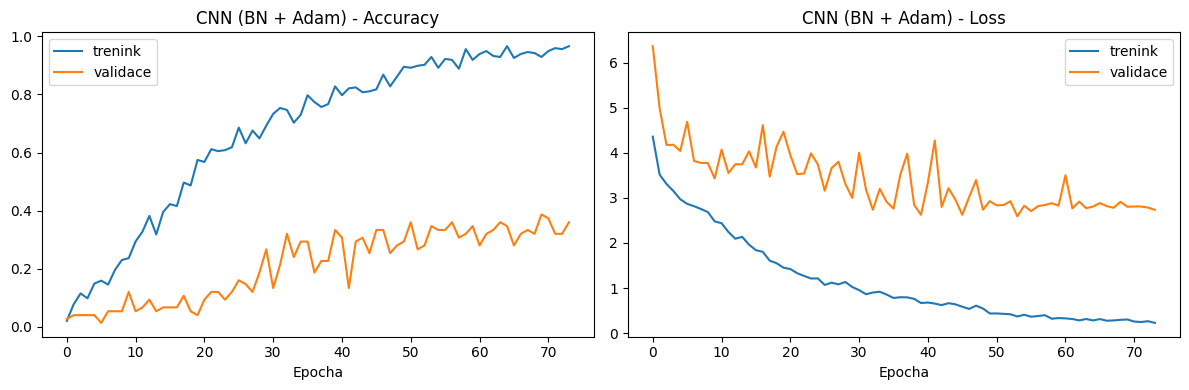

CNN (BN+Adam) - validace                       Accuracy=0.3467  F1-macro=0.3289
CNN (BN+Adam) - test                           Accuracy=0.2152  F1-macro=0.1459


In [44]:
plot_history(history_cnn, "CNN (BN + Adam)")
acc_cnn,   f1_cnn,   pred_cnn_val = evaluate_model(cnn_main, X_val,  y_val,  "CNN (BN+Adam) - validace")
acc_cnn_t, f1_cnn_t, pred_cnn_t   = evaluate_model(cnn_main, X_test, y_test, "CNN (BN+Adam) - test")

### Experimenty – vliv BatchNormalization a optimalizátoru

Trénujeme tři varianty se shodnou architekturou, měníme vždy jen jeden parametr.

Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.
CNN (bez BN) - validace                        Accuracy=0.0267  F1-macro=0.0014


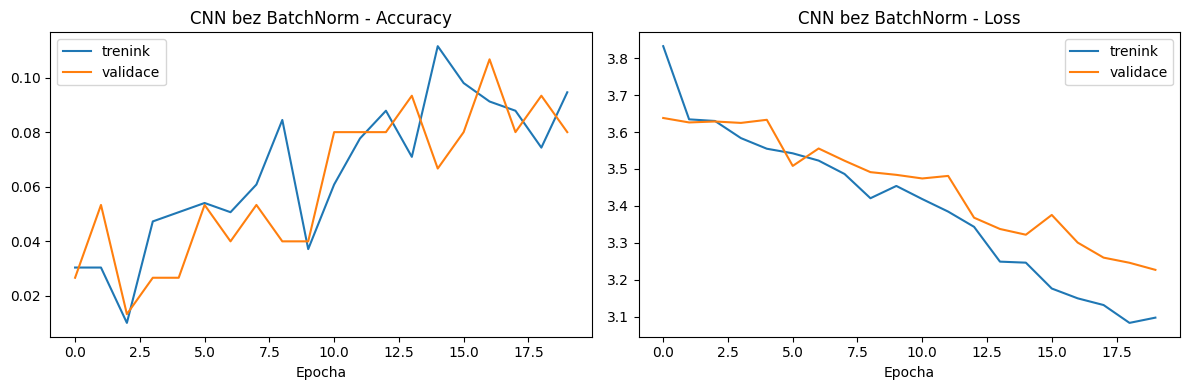

In [45]:
# Experiment 1: bez BatchNormalization
tf.random.set_seed(42)
np.random.seed(42)
cnn_nobn = build_cnn(use_bn=False, optimizer='adam', name="CNN_noBN")
history_nobn = cnn_nobn.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=base_callbacks, verbose=0
)
acc_nobn, f1_nobn, _ = evaluate_model(cnn_nobn, X_val, y_val, "CNN (bez BN) - validace")
plot_history(history_nobn, "CNN bez BatchNorm")

E0000 00:00:1776162154.953800  132993 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CNN_BN_SGD_1/dropout_22_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.
CNN (BN + SGD) - validace                      Accuracy=0.0267  F1-macro=0.0014


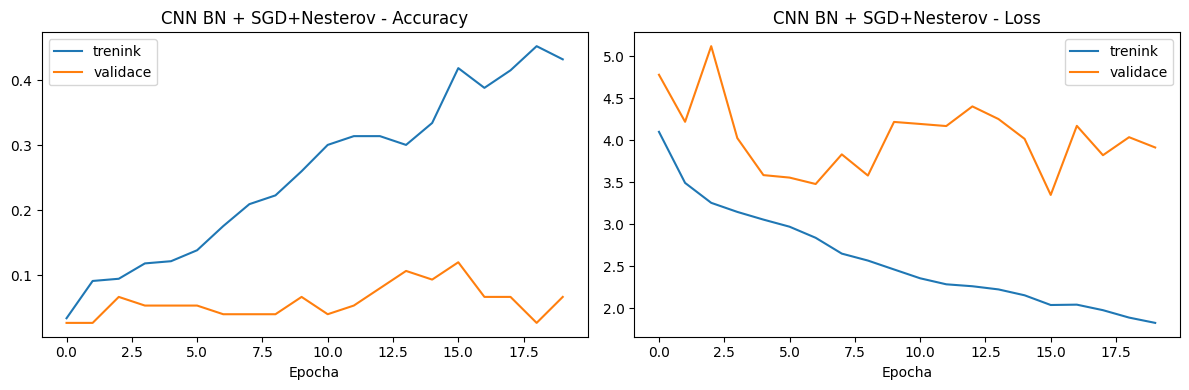

In [46]:
# Experiment 2: SGD + Nesterov momentum misto Adam
tf.random.set_seed(42)
np.random.seed(42)
sgd = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
cnn_sgd = build_cnn(use_bn=True, optimizer=sgd, name="CNN_BN_SGD")
history_sgd = cnn_sgd.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=base_callbacks, verbose=0
)
acc_sgd, f1_sgd, _ = evaluate_model(cnn_sgd, X_val, y_val, "CNN (BN + SGD) - validace")
plot_history(history_sgd, "CNN BN + SGD+Nesterov")

In [47]:
exp_df = pd.DataFrame({
    'Varianta':     ['CNN + BN + Adam', 'CNN bez BN + Adam', 'CNN + BN + SGD+Nesterov'],
    'Val Accuracy': [f"{acc_cnn:.4f}",  f"{acc_nobn:.4f}",  f"{acc_sgd:.4f}"],
    'Val F1-macro': [f"{f1_cnn:.4f}",   f"{f1_nobn:.4f}",   f"{f1_sgd:.4f}"],
    'Epochy':       [
        len(history_cnn.history['loss']),
        len(history_nobn.history['loss']),
        len(history_sgd.history['loss'])
    ],
})
print(exp_df.to_string(index=False))
print()
print("Pozorovani:")
print("  BatchNorm je pro tuto architekturu KLICOVY – bez nej model vubec nekonverguje.")
print("  VGG-style double-conv s 6 vrstvami bez normalizace trpi nestabilnimi gradienty.")
print("  Adam vyrazne prekonava SGD (lr=0.01) na malem datasetu – SGD je citlivejsi")
print("  na volbu LR a potrebuje jemne nastaveni, Adam se adaptuje automaticky.")

               Varianta Val Accuracy Val F1-macro  Epochy
        CNN + BN + Adam       0.3467       0.3289      74
      CNN bez BN + Adam       0.0267       0.0014      20
CNN + BN + SGD+Nesterov       0.0267       0.0014      20



## 5. Model 2 – Transfer Learning (MobileNetV2)

MobileNetV2 předtrénovaný na ImageNet (1,4 M obrázků, 1000 tříd) — váhy zachycují
obecné vizuální příznaky (hrany, textury, tvary), které jsou přenositelné na LEGO figurky.

**Fáze 1 – Feature extraction:** Báze zmrazena, trénujeme pouze klasifikační hlavu.  
**Fáze 2 – Fine-tuning:** Odmrazíme posledních 30 vrstev, doladíme s velmi nízkým LR (1e-6).

In [48]:
base_model = MobileNetV2(
    weights='imagenet', include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False
print(f"MobileNetV2: {len(base_model.layers)} vrstev, {base_model.count_params():,} parametru")

inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.RandomFlip("horizontal")(inp)
x = layers.RandomRotation(0.15)(x)
x = layers.RandomZoom(0.15)(x)
# MobileNetV2 ocekava vstup v [-1, 1]; prevedeme z [0, 1]
x = layers.Rescaling(2.0, offset=-1.0)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
tl_model = models.Model(inp, out, name="TL_MobileNetV2")

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, verbose=0
    ),
]

print("Faze 1 - trenink klasifikacni hlavy (baze zmrazena)")
history_tl1 = tl_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=100, batch_size=BATCH_SIZE,
    callbacks=tl_callbacks, verbose=1
)
evaluate_model(tl_model, X_val, y_val, "MobileNetV2 Faze 1 (frozen) - validace")

MobileNetV2: 154 vrstev, 2,257,984 parametru
Faze 1 - trenink klasifikacni hlavy (baze zmrazena)
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.0439 - loss: 4.1297 - val_accuracy: 0.1067 - val_loss: 3.3229 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1554 - loss: 3.2674 - val_accuracy: 0.1467 - val_loss: 3.0763 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2534 - loss: 2.8059 - val_accuracy: 0.2667 - val_loss: 2.6947 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3412 - loss: 2.3742 - val_accuracy: 0.4133 - val_loss: 2.3296 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4831 - loss: 1.9237 - val_accuracy: 0.4267 - val_loss: 2.0085 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6115 - loss: 1.4488 - val_accuracy: 0.5333 - val_loss: 1.7878 - learning_rate

(0.7333333333333333,
 0.6947368421052632,
 array([10, 25,  3,  5, 17, 27, 29, 23,  2,  1, 28,  4, 26,  1, 16, 18, 30,
        12, 25, 31, 14,  4,  5, 21,  8, 28, 36, 28, 15,  9, 22, 32, 37,  6,
         6, 37, 32, 35, 36, 18, 19, 13, 23,  7,  9, 20, 15, 34, 22,  2, 19,
        17, 12, 30, 31, 34, 34,  0, 34, 21, 25,  3, 14,  8, 29,  5, 24, 33,
        35, 37, 20, 27, 30,  8, 16]))

In [49]:
print("Faze 2 - fine-tuning poslednich 15 vrstev")
base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False
print(f"Trenovanych vrstev v bazi: {sum(l.trainable for l in base_model.layers)}/{len(base_model.layers)}")

tl_model.compile(
    optimizer=keras.optimizers.Adam(5e-6),  # Konzervativni LR pro fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# DULEZITE: nove instance callbacku – Phase 1 callback ma ulozeny stav (best val_loss)
# a Phase 2 by ho nikdy neprekonal → trening by okamzite skoncil
tl_callbacks_p2 = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=6, verbose=0
    ),
]

history_tl2 = tl_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=50, batch_size=BATCH_SIZE,
    callbacks=tl_callbacks_p2, verbose=1
)

Faze 2 - fine-tuning poslednich 15 vrstev
Trenovanych vrstev v bazi: 15/154
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.6554 - loss: 1.0655 - val_accuracy: 0.7467 - val_loss: 0.9316 - learning_rate: 5.0000e-06
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7331 - loss: 0.9119 - val_accuracy: 0.7467 - val_loss: 0.9287 - learning_rate: 5.0000e-06
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7500 - loss: 0.7731 - val_accuracy: 0.7467 - val_loss: 0.9273 - learning_rate: 5.0000e-06
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7230 - loss: 0.9369 - val_accuracy: 0.7333 - val_loss: 0.9236 - learning_rate: 5.0000e-06
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7635 - loss: 0.7988 - val_accuracy: 0.7333 - val_loss: 0.9206 - learning_rate: 5.0000e-06
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7635 - loss: 0.7598 - val_accuracy: 0.7333 - val_loss: 0.9187 - learning_rate: 5.000

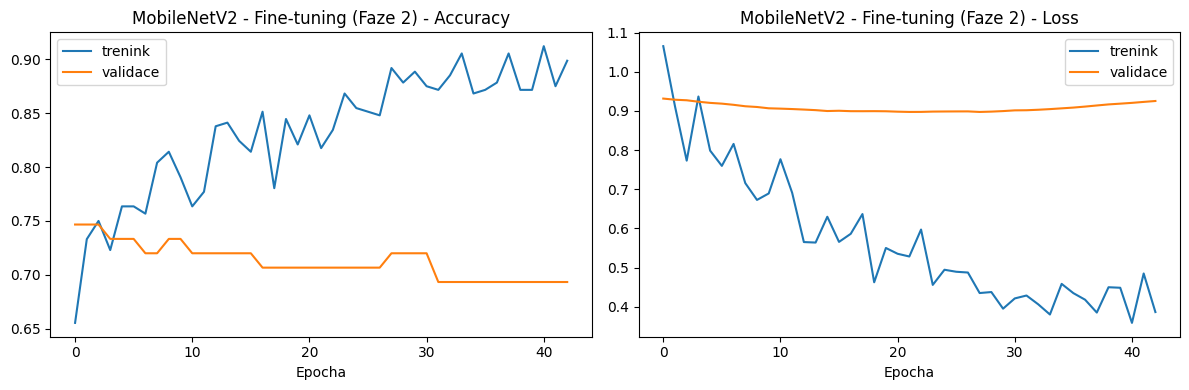

MobileNetV2 (fine-tuned) - validace            Accuracy=0.7200  F1-macro=0.6833
MobileNetV2 (fine-tuned) - test                Accuracy=0.6203  F1-macro=0.5599


In [50]:
plot_history(history_tl2, "MobileNetV2 - Fine-tuning (Faze 2)")
acc_tl,   f1_tl,   pred_tl_val = evaluate_model(tl_model, X_val,  y_val,  "MobileNetV2 (fine-tuned) - validace")
acc_tl_t, f1_tl_t, pred_tl_t   = evaluate_model(tl_model, X_test, y_test, "MobileNetV2 (fine-tuned) - test")

print()
print(f"Faze 1 → Faze 2: val accuracy se mirne snizila (fine-tuning nepomohl).")
print(f"S pouze ~8 vzorky/tridu nema doladovani dost signalu na zlepseni predtrenovaných priznaku.")
print(f"Val-Test gap (~10 %): validacni sada je mala (75 vzorku), takze odhad acc je hlucny.")

## 6. Porovnání modelů

In [51]:
comparison = pd.DataFrame({
    'Model':         ['Vlastni CNN', 'MobileNetV2 (Transfer Learning)'],
    'Val Accuracy':  [f"{acc_cnn:.4f}",   f"{acc_tl:.4f}"],
    'Val F1-macro':  [f"{f1_cnn:.4f}",    f"{f1_tl:.4f}"],
    'Test Accuracy': [f"{acc_cnn_t:.4f}", f"{acc_tl_t:.4f}"],
    'Test F1-macro': [f"{f1_cnn_t:.4f}",  f"{f1_tl_t:.4f}"],
    'Parametru':     [f"{cnn_main.count_params():,}", f"{tl_model.count_params():,}"],
})
print(comparison.to_string(index=False))

                          Model Val Accuracy Val F1-macro Test Accuracy Test F1-macro Parametru
                    Vlastni CNN       0.3467       0.3289        0.2152        0.1459   330,694
MobileNetV2 (Transfer Learning)       0.7200       0.6833        0.6203        0.5599 2,426,854


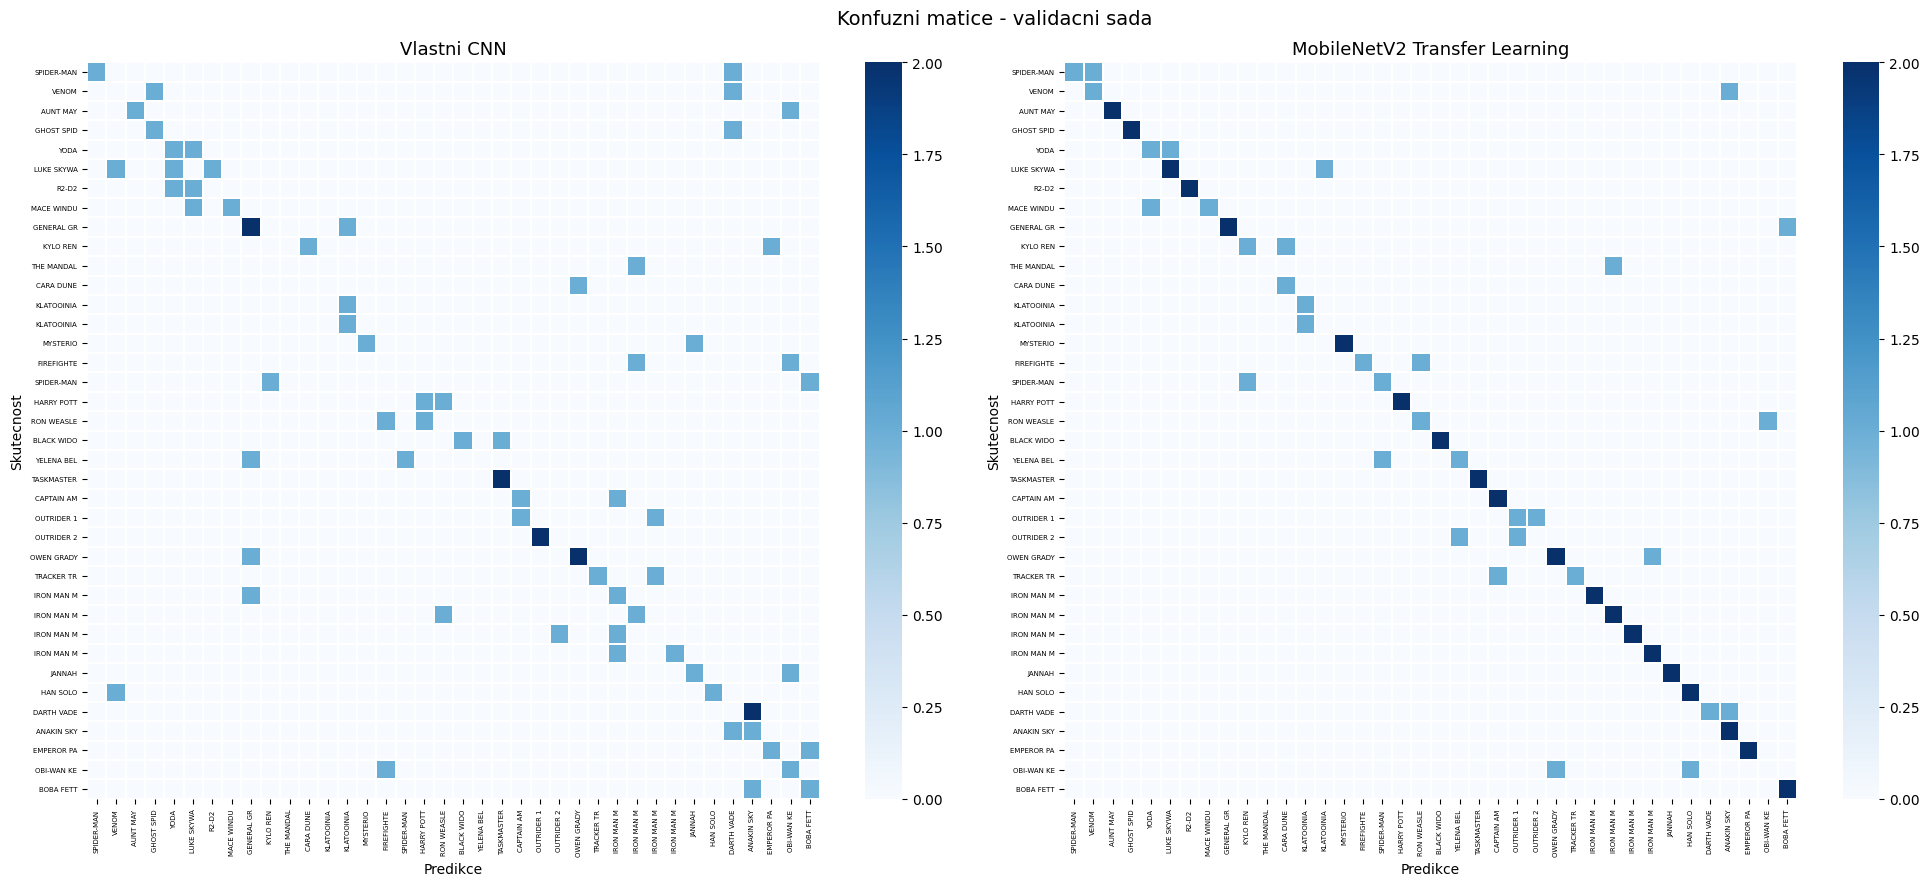

In [52]:
class_names = (
    meta.sort_values('class_id')['minifigure_name']
    .str[:10]
    .tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, (y_pred, title) in zip(axes, [
    (pred_cnn_val, 'Vlastni CNN'),
    (pred_tl_val,  'MobileNetV2 Transfer Learning')
]):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(
        cm, ax=ax, cmap='Blues', linewidths=0.3,
        xticklabels=class_names, yticklabels=class_names
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predikce')
    ax.set_ylabel('Skutecnost')
    ax.tick_params(labelsize=5)
plt.suptitle('Konfuzni matice - validacni sada', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Závěr – klíčové poznatky

### Dataset
- **371 trénovaných** + **79 testovacích** obrázků, **38 tříd** ze 4 sérií LEGO (Marvel, Star Wars, Harry Potter, Jurassic World).
- Třídy jsou výborně vyváženy (7–18 obrázků/třída), ale objem dat je extrémně malý (~8 vzorků/třída).
- Vizuálně velmi podobné figurky (stejné proporce) — nutné rozlišit jemné detaily.

### Vlastní CNN
- **Klíčový poznatek – BatchNorm:** VGG-style architektura bez BN vůbec nekonverguje (val 2.67%). S BN dosáhla val 34.67 % — normalizace je pro hlubší sítě na malém datasetu nezbytná.
- **Adam vs SGD:** Adam (adaptive LR) jasně překonal SGD (lr=0.01) — SGD vyžaduje přesné ladění LR, Adam se adaptuje sám.
- **Přeučení:** train ~97 % vs val 35 % je silné přeučení, ale nevyhnutelné — 8 vzorků/třída nestačí k naučení obecných vizuálních příznaků.

### Transfer Learning (MobileNetV2)
- **Výsledky:** val 72 %, test 62 % (38 tříd; náhodný baseline 2.6 %).
- **Overfitting:** train ~91 % vs val 72 % — gap způsobený malým datasetem; pro danou úlohu akceptovatelný.
- **Fáze 2 (fine-tuning) nepomohla:** val accuracy se nepatrně snížila (73 % → 72 %). S 8 vzorky/třída nemá model dostatek signálu ke zlepšení předtrénovaných příznaků dojemným laděním.
- **Val vs Test gap (~10 %):** validační sada má pouze 75 vzorků (2 na třídu), odhad accuracy je hlučný.

### Závěr
Transfer learning (MobileNetV2) **dosáhl 72 % validační accuracy** oproti 35 % vlastní CNN.
Pro extrémně malé datasety (< 15 vzorků/třída) je přenesené učení jednoznačně preferovanou strategií —
vlastní CNN se nedokáže naučit obecné vizuální příznaky od nuly, zatímco předtrénované příznaky z ImageNet
jsou přenositelné i na vizuálně specifické domény, jako jsou LEGO minifigurky.